# Notebook 02 - Cross-market dependence

This notebook measures how the core markets move together at different sampling frequencies, and whether any market leads another. It works from the fixed input market_data.csv and focuses on a single market pair. It produces the pooled Epps curve, the lead-lag cross-correlation, and a staleness audit, feeding the dependence tables and figures in Chapter 5.

The analysis is run on the most active events. Dependence is measured on log-odds returns of the implied probability, so the series are comparable across markets. To reproduce, place market_data.csv at ../data/raw/ and run all cells in order. Outputs are written to ../outputs/02_correlation_analysis/.

## Code attribution

Library-provided functionality in this notebook: panel construction via pivot, resample, and forward-fill (pandas); correlation (NumPy np.corrcoef); figures (Matplotlib, Seaborn). These are standard tooling and are not attributed line by line.

## 1. Configuration and reproducibility

Fixes the random seed, resolves the input path (and stops early if the file is missing), creates the output folders, and writes a run-metadata file. Nothing here involves model fitting, but the seed is fixed so the pipeline behaves identically on re-runs.

In [1]:
"""
Notebook 02 - Cross-market dependence analysis.

Computes the pooled Epps curve, lead-lag cross-correlation, and a staleness
audit for the focal market pair. Outputs feed Tables 5.1 and 5.5 and the
Epps/lead-lag figures in Chapter 5.

This cell sets paths, fixes the random seed, creates the output directories,
and writes a run-metadata file for reproducibility.
"""

import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone
import random
import numpy as np

# Fixed seed for reproducibility across runs
SEED = 42
NOTEBOOK_NAME = "02_correlation_analysis"

random.seed(SEED)
np.random.seed(SEED)

# Raw tick data (see README for the expected schema)
DATA_PATH = Path("../data/raw/market_data.csv")

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Data file not found at: {DATA_PATH.resolve()}\n"
        "Place market_data.csv in ../data/raw/ (see README)."
    )

# Output directories: figures, tables, and intermediate data
OUTPUT_DIR = Path(f"../outputs/{NOTEBOOK_NAME}")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_OUT_DIR = OUTPUT_DIR / "data" 

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Run metadata written alongside outputs for traceability
metadata = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "notebook": NOTEBOOK_NAME,
    "seed": SEED,
    "python_version": sys.version.split()[0],
    "data_file": DATA_PATH.name
}

with open(OUTPUT_DIR / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")

Data path: ..\data\raw\market_data.csv
Output directory: ..\outputs\02_correlation_analysis
Random seed: 42


## 2. Libraries and plot settings

The analysis stack (pandas, matplotlib, seaborn) and the global plot and display settings.

In [2]:
"""Library imports and global plot/display settings."""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot defaults: whitegrid style, 300 dpi for saved figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

# Show all columns, 4 decimal places
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 3. Output helpers

save_figure writes each figure as both PNG and PDF; save_table writes each table as both CSV and LaTeX, so every output is regenerated to a known file path.

In [3]:
"""Output helpers: save figures as PNG/PDF and tables as CSV/LaTeX."""

def save_figure(name, fig=None):
    """Save the current (or given) figure as both PNG and PDF."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig = fig or plt.gcf()

    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"

    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved: {png_path.name}, {pdf_path.name}")
    return png_path, pdf_path


def save_table(df, name, index=False):
    """Save a DataFrame as both CSV and a LaTeX table (4 decimal places)."""
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

    csv_path = TABLE_DIR / f"{name}.csv"
    tex_path = TABLE_DIR / f"{name}.tex"

    df.to_csv(csv_path, index=index)
    df.to_latex(tex_path, index=index, float_format="%.4f")

    print(f"Saved: {csv_path.name}, {tex_path.name}")
    return csv_path, tex_path

## 4. Constants

The three core markets and their short codes (MO, OU25, BTTS) used in the output tables.

In [4]:
"""Core markets analysed and their short codes used in output tables."""

CORE_MARKETS = [
    "Match Odds",
    "Over/Under 2.5 Goals",
    "Both teams to Score?"
]

# Long market name -> short code (MO, OU25, BTTS)
MARKET_CODE_MAP = {
    "Match Odds": "MO",
    "Over/Under 2.5 Goals": "OU25",
    "Both teams to Score?": "BTTS"
}

## 5. Loading and the liquid cohort

load_and_filter_time reads the CSV, checks the required columns, parses timestamps as UTC, keeps pre-match rows, computes time-to-kick-off, and restricts to the final 360 minutes. select_liquid_cohort returns the most active events by tick count, used as the cohort for the dependence analysis.

In [ ]:
def load_and_filter_time(path: Path, min_tau: float = 0, max_tau: float = 360) -> pd.DataFrame:
    """
    Load the raw tick data and restrict to pre-match observations within
    [min_tau, max_tau] minutes to kick-off.
    """
    print(">> Loading Data...")
    df_raw = pd.read_csv(path)

    df = df_raw.copy()

    # Required columns must be present
    required_cols = {"event_id", "ts_utc", "market_time"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # Parse timestamps - unparseable rows become NaT
    df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True, errors="coerce")
    df["market_time"] = pd.to_datetime(df["market_time"], utc=True, errors="coerce")

    # Drop rows with timestamps that failed to parse
    df = df.dropna(subset=["ts_utc", "market_time"])

    # Keep pre-match rows only (quote time before kick-off)
    df = df[df["ts_utc"] < df["market_time"]].copy()

    # tau = minutes from quote time to kick-off
    df["tau_minutes"] = (df["market_time"] - df["ts_utc"]).dt.total_seconds() / 60.0

    # Restrict to the analysis window
    df = df[df["tau_minutes"].between(min_tau, max_tau)].copy()

    print(">> Done.")
    print("   rows:", df.shape[0], "| events:", df["event_id"].nunique())
    return df


def select_liquid_cohort(df: pd.DataFrame, n: int = 10) -> list:
    """Return the top-n events by tick count (activity proxy for liquidity)."""
    event_activity = df.groupby("event_id").size().sort_values(ascending=False)
    return event_activity.head(n).index.tolist()

## 6. Building the log-odds panel

These functions turn one event's raw ticks into the series the analysis uses. robust_log_odds_prob_panel builds a one-minute panel: it pivots quotes wide, resamples to bars with the last quote forward-filled (the standing quote), treats zero prices as missing, filters out bars with a missing side or a wide spread, takes the mid in odds space, and converts the implied probability to log-odds. build_minute_panel_logodds_prob_RETURNS wraps this to also return five-minute log-odds returns, restricted to the core markets.

In [6]:
def shorten_names(cols) -> list:
    """
    Replace long market names in column labels with short codes.
    e.g. 'Over/Under 2.5 Goals_Over 2.5 Goals' -> 'OU25_Over 2.5 Goals'
    """
    if "MARKET_CODE_MAP" not in globals():
         raise NameError("MARKET_CODE_MAP is not defined. Define it before calling shorten_names().")
    new_cols = []
    for c in cols:
        name = c
        for long, short in MARKET_CODE_MAP.items():
            name = name.replace(long, short)
        new_cols.append(name)
    return new_cols


def robust_log_odds_prob_panel(
    df_event: pd.DataFrame,
    max_spread_pct: float = 0.20,
    bar_freq: str = "1min",
    max_gap: int = 5
) -> pd.DataFrame:
    """
    Build a 1-minute log-odds-prob panel for a single event.

    Steps:
      - Pivot ticks wide, keyed by series_id (market_name + selection_name).
      - Resample to bar_freq using the last quote, forward-filled up to
        max_gap bars (standing-quote state).
      - Compute the mid in odds space; drop bars with a missing side or a
        spread wider than max_spread_pct.
      - Convert the implied probability to log-odds-prob.
    """
    df = df_event.copy()

    required = {"ts_utc", "market_name", "selection_name", "best_back_price", "best_lay_price"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"robust_log_odds_panel: missing required columns: {sorted(missing)}")

    # Ensure timestamps are datetime
    if not pd.api.types.is_datetime64_any_dtype(df["ts_utc"]):
        df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)

    df = df.sort_values("ts_utc")

    # One column per market/selection
    df["series_id"] = df["market_name"] + "_" + df["selection_name"]

    # Pivot ticks into a wide panel of back/lay prices
    df_pivot = df.pivot_table(
        index="ts_utc",
        columns="series_id",
        values=["best_back_price", "best_lay_price"],
        aggfunc="last",
    )

    # Resample to 1-min bars: last quote, forward-filled over short gaps
    df_bars = df_pivot.resample(bar_freq).last().ffill(limit=max_gap)

    # Zero prices are not real quotes -> treat as missing
    back_df = df_bars["best_back_price"].replace(0, np.nan)
    lay_df  = df_bars["best_lay_price"].replace(0, np.nan)

    # Both sides must be present
    valid_quotes = back_df.notna() & lay_df.notna()

    # Spread filter (relative to back price)
    spread = lay_df - back_df
    spread_pct = spread / back_df
    tight_spread = spread_pct < max_spread_pct

    # Mid in odds space, kept only where the bar passes both filters
    mid_odds = (back_df + lay_df) / 2.0
    mid_odds = mid_odds.where(valid_quotes & tight_spread)

    # Implied probability, clipped off the {0,1} boundary, then log-odds-prob
    probs = 1.0 / mid_odds
    eps = 1e-4
    probs = probs.clip(lower=eps, upper=1 - eps)
    log_odds_prob = np.log(probs / (1 - probs))

    return log_odds_prob.dropna(how="all")


def build_minute_panel_logodds_prob_RETURNS(df_all: pd.DataFrame, event_id, max_gap: int = 5):
    """
    Build, for a single event:
      1) the 1-min log-odds-prob state panel
      2) the 5-min log-odds-prob returns (diff of the 5-min last value)
    Restricted to CORE_MARKETS. Returns (None, None) if the event has no usable data.
    """
    if "CORE_MARKETS" not in globals():
        raise NameError("CORE_MARKETS is not defined. Define it before calling build_minute_panel_logodds_prob_RETURNS().")
    df_evt = df_all[
        (df_all["event_id"] == event_id)
        & (df_all["market_name"].isin(CORE_MARKETS))
    ].copy()

    if df_evt.empty:
        return None, None

    df_1min_log_odds_prob = robust_log_odds_prob_panel(df_evt, max_spread_pct=0.20, bar_freq="1min", max_gap = max_gap)
    if df_1min_log_odds_prob is None or df_1min_log_odds_prob.empty:
        return None, None

    # 5-min returns from the 1-min state
    df_5min_state = df_1min_log_odds_prob.resample("5min").last()
    df_rets = df_5min_state.diff()

    return df_1min_log_odds_prob, df_rets

## 7. Epps curve, lead-lag, and staleness functions

The analysis functions. compute_pooled_epps_curve pools paired returns across events at each sampling horizon and computes the pooled correlation, giving the Epps curve. get_pooled_ccf computes the pooled cross-correlation at a range of positive and negative lags, using index-based alignment so positive and negative lags are treated symmetrically. calculate_staleness audits the fraction of exactly-zero returns per series, which flags series that update infrequently. Each is paired with a plotting helper.

In [ ]:
# Pooled Epps-curve - pooling paired returns across events at each sampling horizon and correlating

def compute_pooled_epps_curve(df: pd.DataFrame, event_ids: list, pair_x: str, pair_y: str, intervals=(5, 15, 30, 60)):
    """
    Pooled Epps curve. For each sampling horizon, resample the 5-min returns
    to that horizon (sum), pool the paired observations across events, and
    compute the pooled correlation between pair_x and pair_y.
    """
    pooled_curve = []
    pooled_n = []

    for mins in intervals:
        all_x, all_y = [], []

        # Pool paired returns across all events
        for eid in event_ids:
            _, df_rets = build_minute_panel_logodds_prob_RETURNS(df, eid, max_gap=5)
            if df_rets is None:
                continue

            df_rets.columns = shorten_names(df_rets.columns)

            # Aggregate 5-min returns
            df_res = df_rets.resample(f"{mins}min").sum().dropna(how="all")

            if pair_x in df_res.columns and pair_y in df_res.columns:
                valid = df_res.dropna(subset=[pair_x, pair_y])
                if not valid.empty:
                    all_x.extend(valid[pair_x].values)
                    all_y.extend(valid[pair_y].values)

        # Pooled correlation, with a minimum sample guard
        if len(all_x) > 10:
            corr = np.corrcoef(all_x, all_y)[0, 1]
            pooled_curve.append(corr)
            print(f"Horizon {mins}m: Corr={corr:.4f} (N={len(all_x)})")
            pooled_n.append(len(all_x))
        else:
            pooled_curve.append(np.nan)
            print(f"Horizon {mins}m: Insufficient Data")
            pooled_n.append(len(all_x))

    return list(intervals), pooled_curve, pooled_n


def plot_epps_curve(intervals, pooled_curve, pair_x: str, pair_y: str, save_name: str = None):
    """Plot the pooled correlation against sampling interval."""
    plt.figure(figsize=(10, 6))
    plt.plot(intervals, pooled_curve, marker="o", markersize=8, linestyle="-", linewidth=2.5, label="Pooled cohort")
    plt.axhline(0.0, linestyle="--", linewidth=1.5, label="High-frequency baseline (0)")
    plt.xlabel("Sampling Interval (Minutes)")
    plt.ylabel(r"Correlation ($\Delta\,\mathrm{logit}(p)$): " + f"{pair_x} vs {pair_y}")
    plt.xticks(intervals)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

    if save_name:
        save_figure(Path(save_name).stem)

    plt.show()


def get_pooled_ccf(df_all, event_ids, pair_x, pair_y, max_lag=10):
    """
    Pooled cross-correlation of returns at +/- lags (in 5-min periods).
    CCF(k) = Corr( ret_x(t), ret_y(t+k) ); positive k => pair_x leads pair_y.
    Alignment is index-based, so negative and positive lags are treated
    symmetrically
    """
    lags = range(-max_lag, max_lag + 1)
    ccf_values = []

    freq = "5min"
    print(f"Calculating Lead-Lag for {pair_x} vs {pair_y} (Freq: {freq})...")

    for lag in lags:
        pooled_x = []
        pooled_y_lagged = []

        # Pool the aligned (x, shifted-y) pairs across events at this lag
        for eid in event_ids:
            df_1min, _ = build_minute_panel_logodds_prob_RETURNS(df_all, eid, max_gap=5)
            if df_1min is None:
                continue

            df_1min.columns = shorten_names(df_1min.columns)
            if pair_x not in df_1min.columns or pair_y not in df_1min.columns:
                continue

            df_res = df_1min[[pair_x, pair_y]].resample(freq).last()
            df_rets = df_res.diff().dropna()
            if df_rets.empty:
                continue

            # Shift ret_y so that row t holds ret_y(t+lag), then align on the
            # shared timestamp index and drop only the boundary NaNs.
            aligned = pd.concat(
                [df_rets[pair_x], df_rets[pair_y].shift(-lag)],
                axis=1,
            ).dropna()

            if not aligned.empty:
                pooled_x.extend(aligned.iloc[:, 0].values)
                pooled_y_lagged.extend(aligned.iloc[:, 1].values)

        # Pooled correlation at this lag, with a minimum sample guard
        if len(pooled_x) > 50:
            c = np.corrcoef(pooled_x, pooled_y_lagged)[0, 1]
            ccf_values.append(c)
        else:
            ccf_values.append(np.nan)

    return pd.Series(ccf_values, index=list(lags))


def plot_ccf(ccf_series: pd.Series, target_x: str, target_y: str, save_name: str = None):
    """Bar plot of the cross-correlation by lag."""
    plt.figure(figsize=(10, 5))
    colors = ["red" if x < 0 else "teal" for x in ccf_series.values]
    ccf_series.plot(kind="bar", color=colors, edgecolor="black")

    plt.axhline(0, color="black", linewidth=0.8)
    plt.xlabel(f"Lag (5-min periods)\nNegative: {target_y} moves first | Positive: {target_x} moves first")
    plt.ylabel("Correlation Coefficient")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

    if save_name:
        save_figure(Path(save_name).stem)

    plt.show()


def calculate_staleness(df_all, event_ids, threshold=0.50):
    """
    Staleness audit: fraction of exactly-zero 5-min returns per series.
    A high zero-return fraction indicates a series that updates infrequently.
    """
    staleness_stats = []
    keys = ["OU25_Over 2.5 Goals", "BTTS_Yes"]

    print(f"--- Running Staleness Audit on {len(event_ids)} Events ---")

    for eid in event_ids:
        _, df_rets = build_minute_panel_logodds_prob_RETURNS(df_all, eid, max_gap=5)
        if df_rets is None or df_rets.empty:
            continue

        df_rets.columns = shorten_names(df_rets.columns)

        # Per series, fraction of returns that are exactly zero
        row = {"event_id": eid}
        for k in keys:
            if k in df_rets.columns:
                s = df_rets[k].dropna()
                row[k] = (s == 0.0).mean() if len(s) else np.nan
            else:
                row[k] = np.nan

        staleness_stats.append(row)

    df_stale = pd.DataFrame(staleness_stats)

    print("\n--- Staleness Results (Fraction of Zero Returns) ---")
    print(df_stale.describe())

    # Distribution of staleness per market
    plt.figure(figsize=(10, 5))
    df_melt = df_stale.melt(
        id_vars="event_id",
        value_vars=["OU25_Over 2.5 Goals", "BTTS_Yes"],
        var_name="Market",
        value_name="Staleness",
    )
    sns.boxplot(x="Market", y="Staleness", data=df_melt)
    plt.axhline(threshold, color="red", linestyle="--", label=f"Danger Zone (>{threshold:.0%})")
    plt.ylabel("Fraction of Zero Returns (5-min)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    avg_stale_ou = df_stale["OU25_Over 2.5 Goals"].mean()
    avg_stale_btts = df_stale["BTTS_Yes"].mean()

    print("\nVERDICT:")
    print(f"Over 2.5 Staleness: {avg_stale_ou:.1%}")
    print(f"BTTS Staleness:     {avg_stale_btts:.1%}")

    # Flag if the less liquid series is predominantly stale
    if avg_stale_btts > threshold:
        print("\n[!] CRITICAL: BTTS is predominantly stale.")
        print("    Correlation may be driven by 'wake-up' events, not continuous price discovery.")
    else:
        print("\n[OK] Staleness is within acceptable limits.")

    return df_stale

## 8. Main execution

Runs the analysis in order: load the data, select the liquid cohort, compute the Epps curve for the focal pair, compute the lead-lag cross-correlation, run the staleness audit, and export the results tables. The focal pair is Over/Under 2.5 (Over) against Both Teams To Score (Yes).

>> Loading Data...
>> Done.
   rows: 11384468 | events: 290
Top liquid events: [27594373, 27674404, 27622367, 27651076, 27503243, 27624613, 27707995, 27560367, 27608856, 27508951, 27631564, 27594377, 27608854, 27532129, 27526154, 27601772, 27644595, 27608851, 27624592, 27538776, 27594371, 27644597, 27624612, 27635181, 27581491, 27616091, 27616080, 27616088, 27644600, 27715954, 27732434, 27747477, 27732438, 27699522, 27747472, 27503242, 27651077, 27651078, 27538772, 27629597, 27468374, 27581490, 27608852, 27635178, 27635286, 27755225, 27739618, 27601774, 27526085, 27651079, 27574354, 27707977, 27514471, 27616092, 27622364, 27622365, 27635180, 27574356, 27631562, 27601780, 27747484, 27468364, 27532158, 27755258, 27508949, 27545690, 27667218, 27667216, 27693127, 27574353, 27747474, 27667227, 27732436, 27688830, 27468375, 27545687, 27635283, 27601778, 27642083, 27526382, 27699513, 27664005, 27674400, 27526381, 27601781, 27699511, 27622362, 27503240, 27581493, 27616094, 27538774, 27616081, 

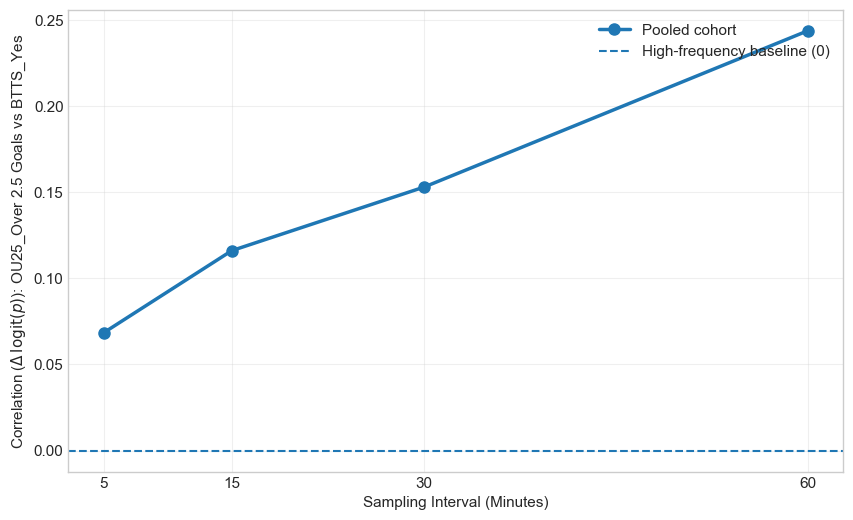

Calculating Lead-Lag for OU25_Over 2.5 Goals vs BTTS_Yes (Freq: 5min)...
Saved: fig_5_5_leadlag.png, fig_5_5_leadlag.pdf


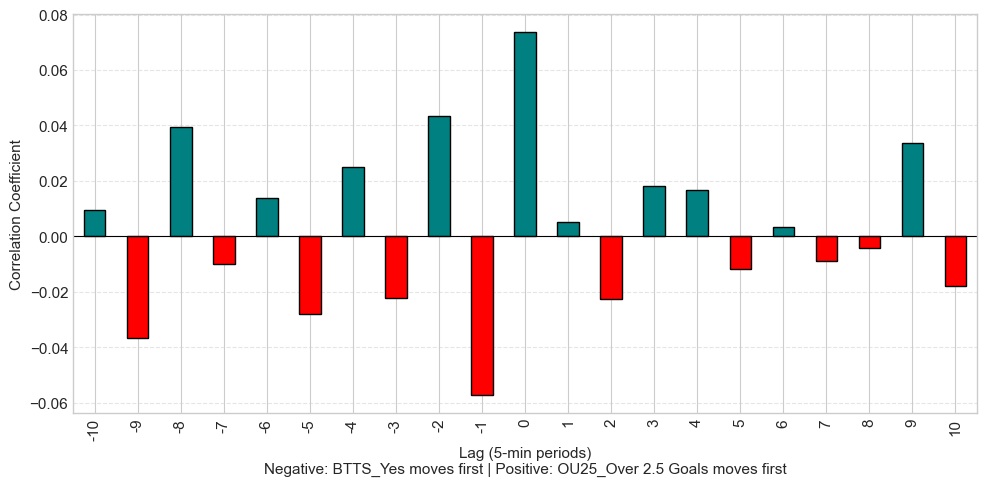

Correlation by lag:
 -10    0.0096
-9    -0.0365
-8     0.0396
-7    -0.0098
-6     0.0137
-5    -0.0281
-4     0.0251
-3    -0.0220
-2     0.0436
-1    -0.0571
 0     0.0735
 1     0.0053
 2    -0.0227
 3     0.0182
 4     0.0168
 5    -0.0118
 6     0.0035
 7    -0.0090
 8    -0.0042
 9     0.0339
 10   -0.0178
dtype: float64
--- Running Staleness Audit on 100 Events ---

--- Staleness Results (Fraction of Zero Returns) ---
           event_id  OU25_Over 2.5 Goals  BTTS_Yes
count      100.0000             100.0000  100.0000
mean  27620686.7600               0.1988    0.1902
std      73661.1795               0.0632    0.0667
min   27468364.0000               0.0704    0.0351
25%   27574355.5000               0.1583    0.1406
50%   27622364.5000               0.1884    0.1811
75%   27667216.5000               0.2409    0.2368
max   27755258.0000               0.4179    0.3833


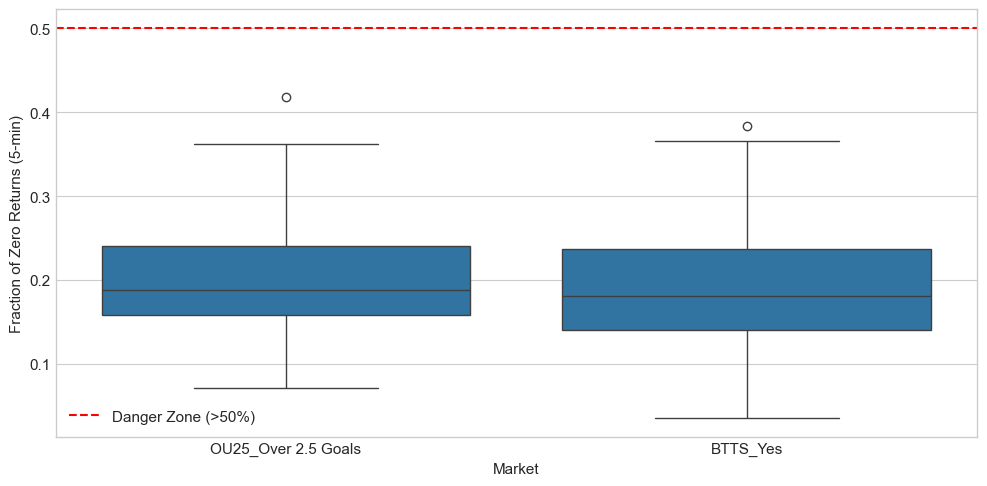


VERDICT:
Over 2.5 Staleness: 19.9%
BTTS Staleness:     19.0%

[OK] Staleness is within acceptable limits.
Saved: staleness_audit.csv, staleness_audit.tex
Saved: tab_5_1_epps.csv, tab_5_1_epps.tex
Saved: tab_5_5_ccf_by_lag.csv, tab_5_5_ccf_by_lag.tex
Saved tables to: ..\outputs\02_correlation_analysis


In [ ]:
# Main execution

# Load ticks and restrict to the final 360 minutes pre-match
df = load_and_filter_time(DATA_PATH, min_tau=0, max_tau=360)

# Liquid cohort: top-N most active events (N reported in the writeup)
liquid_cohort = select_liquid_cohort(df, n=100)
print("Top liquid events:", liquid_cohort)

# Focal pair for the dependence analysis
pair_x = "OU25_Over 2.5 Goals"
pair_y = "BTTS_Yes"

# Epps curve: pooled correlation across sampling horizons
intervals, pooled_curve, pooled_n = compute_pooled_epps_curve(
    df,
    event_ids=liquid_cohort,
    pair_x=pair_x,
    pair_y=pair_y,
    intervals=(5, 15, 30, 60),
)
plot_epps_curve(intervals, pooled_curve, pair_x, pair_y, save_name="fig_5_4_epps_curve.png")

# Lead-lag cross-correlation (index-aware alignment)
ccf_series = get_pooled_ccf(df, liquid_cohort, pair_x=pair_x, pair_y=pair_y, max_lag=10)
plot_ccf(ccf_series, target_x=pair_x, target_y=pair_y, save_name="fig_5_5_leadlag.png")
print("Correlation by lag:\n", ccf_series)

# Staleness audit: checks whether fine-frequency correlation is driven by flat series
df_staleness = calculate_staleness(df, liquid_cohort, threshold=0.50)

# --- Exports ---
save_table(df_staleness, "staleness_audit", index=False)

# Epps results -> Table 5.1
df_epps = pd.DataFrame({
    "Horizon": [f"{m}m" for m in intervals],
    "Correlation": pooled_curve,
    "N": pooled_n,
})
save_table(df_epps, "tab_5_1_epps", index=False)

# Lead-lag values by lag
save_table(ccf_series.rename("corr").to_frame(), "tab_5_5_ccf_by_lag", index=True)

print("Saved tables to:", OUTPUT_DIR)